<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_spectral_memory_readout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

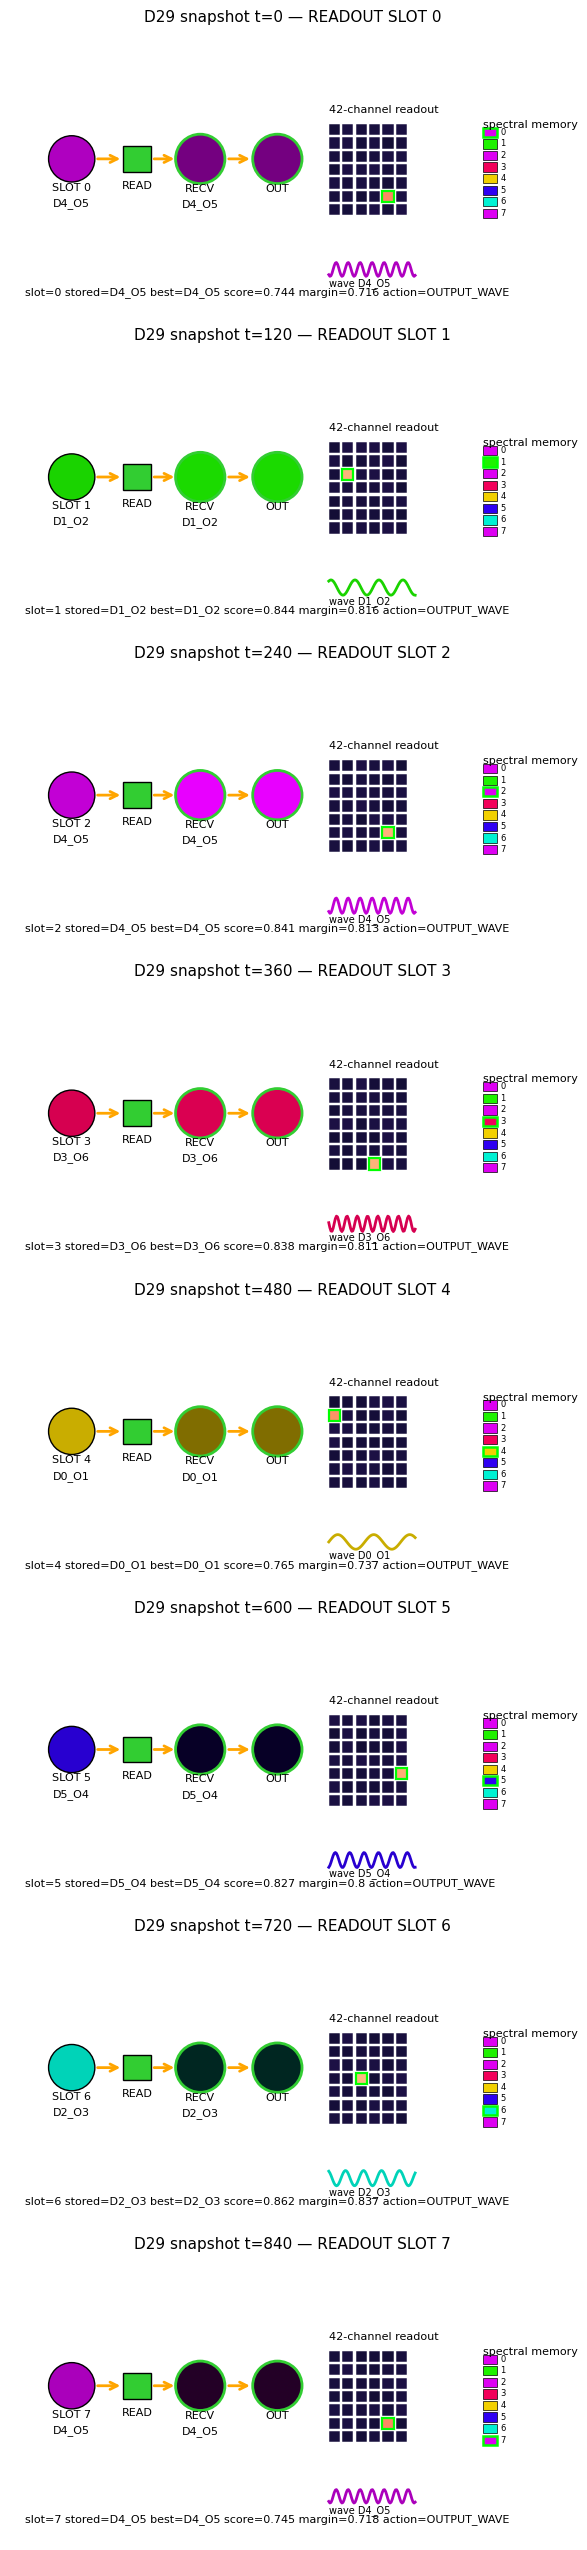

STATE: SPECTRAL_MEMORY_READOUT_LOCKED
spectral states:              42
directions x octaves:         6 x 7
memory slots:                 8
stored spectral sequence:     D4_O5 D1_O2 D4_O5 D3_O6 D0_O1 D5_O4 D2_O3 D4_O5
readout spectral sequence:    D4_O5 D1_O2 D4_O5 D3_O6 D0_O1 D5_O4 D2_O3 D4_O5
readout accuracy:             1.0
wave reconstruction accuracy: 1.0
safety accuracy:              1.0
retention threshold:          0.5
readout threshold:            0.62
ambiguity margin:             0.12

Spectral memory readout table:


,STATE,MEMORY_SLOT,STORED_KEY,STORED_STATE_ID,RETAINED_STRENGTH,BEST_KEY,BEST_STATE_ID,BEST_SCORE,SECOND_KEY,SECOND_SCORE,MARGIN,HELD,READOUT_KEY,MATCH
0,D29_SPECTRAL_MEMORY_READOUT,0,D4_O5,34,0.754,D4_O5,34,0.744,D5_O6,0.028,0.716,1,D4_O5,1
1,D29_SPECTRAL_MEMORY_READOUT,1,D1_O2,13,0.826,D1_O2,13,0.844,D4_O3,0.027,0.816,1,D1_O2,1
2,D29_SPECTRAL_MEMORY_READOUT,2,D4_O5,34,0.835,D4_O5,34,0.841,D0_O2,0.028,0.813,1,D4_O5,1
3,D29_SPECTRAL_MEMORY_READOUT,3,D3_O6,39,0.840,D3_O6,39,0.838,D4_O4,0.028,0.811,1,D3_O6,1
4,D29_SPECTRAL_MEMORY_READOUT,4,D0_O1,6,0.790,D0_O1,6,0.765,D1_O5,0.028,0.737,1,D0_O1,1
5,D29_SPECTRAL_MEMORY_READOUT,5,D5_O4,29,0.815,D5_O4,29,0.827,D5_O3,0.028,0.800,1,D5_O4,1
6,D29_SPECTRAL_MEMORY_READOUT,6,D2_O3,20,0.826,D2_O3,20,0.862,D0_O2,0.026,0.837,1,D2_O3,1
7,D29_SPECTRAL_MEMORY_READOUT,7,D4_O5,34,0.733,D4_O5,34,0.745,D5_O4,0.027,0.718,1,D4_O5,1



Output wave reconstruction table:


,STATE,MEMORY_SLOT,READOUT_KEY,DIRECTION,OCTAVE,STATE_ID,WAVE_PHASE,WAVE_FREQUENCY,OUTPUT_TOKEN,MATCH
0,D29_SPECTRAL_MEMORY_READOUT,0,D4_O5,4,5,34,0.667,6,WAVE[D4|O5|F6|P0.667],1
1,D29_SPECTRAL_MEMORY_READOUT,1,D1_O2,1,2,13,0.167,3,WAVE[D1|O2|F3|P0.167],1
2,D29_SPECTRAL_MEMORY_READOUT,2,D4_O5,4,5,34,0.667,6,WAVE[D4|O5|F6|P0.667],1
3,D29_SPECTRAL_MEMORY_READOUT,3,D3_O6,3,6,39,0.500,7,WAVE[D3|O6|F7|P0.5],1
4,D29_SPECTRAL_MEMORY_READOUT,4,D0_O1,0,1,6,0.000,2,WAVE[D0|O1|F2|P0.0],1
5,D29_SPECTRAL_MEMORY_READOUT,5,D5_O4,5,4,29,0.833,5,WAVE[D5|O4|F5|P0.833],1
6,D29_SPECTRAL_MEMORY_READOUT,6,D2_O3,2,3,20,0.333,4,WAVE[D2|O3|F4|P0.333],1
7,D29_SPECTRAL_MEMORY_READOUT,7,D4_O5,4,5,34,0.667,6,WAVE[D4|O5|F6|P0.667],1



Readout safety table:


,STATE,CASE,EXPECTED,BEST_KEY,BEST_SCORE,SECOND_KEY,SECOND_SCORE,MARGIN,ACCEPTED_KEY,SAFETY_OK
0,D29_SPECTRAL_MEMORY_READOUT,EMPTY_MEMORY_SLOT,NONE,D1_O3,0.034,D2_O3,0.033,0.001,NONE,1
1,D29_SPECTRAL_MEMORY_READOUT,WEAK_RETENTION,NONE,D4_O5,0.380,D1_O0,0.025,0.355,NONE,1
2,D29_SPECTRAL_MEMORY_READOUT,AMBIGUOUS_TWO_STATES,NONE,D2_O3,0.830,D4_O5,0.780,0.050,NONE,1
3,D29_SPECTRAL_MEMORY_READOUT,WRONG_STATE_STRONG,D0_O6,D0_O6,0.860,D3_O1,0.023,0.837,D0_O6,1



Summary:


,STATE,RESULT,SPECTRAL_STATES,DIRECTIONS,OCTAVES,MEMORY_SLOTS,STORED_SPECTRAL_SEQUENCE,READOUT_SPECTRAL_SEQUENCE,READOUT_ACCURACY,WAVE_RECONSTRUCTION_ACCURACY,SAFETY_ACCURACY,RETENTION_THRESHOLD,READOUT_THRESHOLD,AMBIGUITY_MARGIN
0,D29_SPECTRAL_MEMORY_READOUT,SPECTRAL_MEMORY_READOUT_LOCKED,42,6,7,8,D4_O5 D1_O2 D4_O5 D3_O6 D0_O1 D5_O4 D2_O3 D4_O5,D4_O5 D1_O2 D4_O5 D3_O6 D0_O1 D5_O4 D2_O3 D4_O5,1.0,1.0,1.0,0.5,0.62,0.12


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
from IPython.display import display

# ============================================================
# D29_SPECTRAL_MEMORY_READOUT
# Field memory spectral readout and output-wave reconstruction
#
# Goal:
# stored 42-state spectral memory
# -> read retained spectral state from each slot
# -> reconstruct 42-channel spectral packets
# -> decode direction/octave keys
# -> rebuild output wave sequence
# -> verify readout accuracy and rejection safety
# ============================================================

np.random.seed(29)

STATE = "D29_SPECTRAL_MEMORY_READOUT"

directions = 6
octaves = 7
spectral_states = directions * octaves

memory_slots = 8

input_spectral_sequence = [
    "D4_O5",
    "D1_O2",
    "D4_O5",
    "D3_O6",
    "D0_O1",
    "D5_O4",
    "D2_O3",
    "D4_O5",
]

# Retention values copied in spirit from D28:
# each stored state still has enough strength to be read.
retained_strengths = [0.754, 0.826, 0.835, 0.840, 0.790, 0.815, 0.826, 0.733]

retention_threshold = 0.50
readout_threshold = 0.62
ambiguity_margin = 0.12


# ------------------------------------------------------------
# Spectral key helpers
# ------------------------------------------------------------

def parse_key(key):
    # key format: D4_O5
    d_part, o_part = key.split("_")
    direction = int(d_part.replace("D", ""))
    octave = int(o_part.replace("O", ""))
    return direction, octave


def key_to_state_id(key):
    direction, octave = parse_key(key)
    return octave * directions + direction


def state_id_to_key(state_id):
    octave = state_id // directions
    direction = state_id % directions
    return f"D{direction}_O{octave}"


def key_color(key, strength=1.0):
    if key == "NONE" or key is None:
        return "black"

    sid = key_to_state_id(key)
    hue = sid / max(1, spectral_states - 1)
    base = plt.cm.hsv(hue)

    # Blend toward dark when strength is weak
    s = float(np.clip(strength, 0.15, 1.0))
    return (base[0] * s, base[1] * s, base[2] * s, 1.0)


def make_packet(target_key=None, strength=0.85, noise=0.025, ambiguous_key=None, ambiguous_strength=0.0):
    packet = np.random.uniform(0.0, noise, spectral_states)

    if target_key is not None and target_key != "NONE":
        target_id = key_to_state_id(target_key)
        packet[target_id] = strength

    if ambiguous_key is not None and ambiguous_key != "NONE":
        ambiguous_id = key_to_state_id(ambiguous_key)
        packet[ambiguous_id] = ambiguous_strength

    return np.clip(packet, 0.0, 1.0)


def decode_packet(packet):
    ordered = np.argsort(packet)[::-1]
    best_id = int(ordered[0])
    second_id = int(ordered[1])

    best_score = float(packet[best_id])
    second_score = float(packet[second_id])
    margin = best_score - second_score

    best_key = state_id_to_key(best_id)

    accepted = int(best_score >= readout_threshold and margin >= ambiguity_margin)

    return {
        "best_id": best_id,
        "best_key": best_key,
        "best_score": best_score,
        "second_id": second_id,
        "second_key": state_id_to_key(second_id),
        "second_score": second_score,
        "margin": margin,
        "accepted": accepted,
    }


def wave_signature_from_key(key):
    direction, octave = parse_key(key)

    phase = round(direction / directions, 3)
    frequency = octave + 1
    token = f"WAVE[D{direction}|O{octave}|F{frequency}|P{phase}]"

    return phase, frequency, token


# ------------------------------------------------------------
# Read stored spectral memory
# ------------------------------------------------------------

stored_keys = input_spectral_sequence.copy()
stored_state_ids = [key_to_state_id(k) for k in stored_keys]

readout_rows = []
wave_rows = []
packets = []
readout_keys = []
output_wave_tokens = []

for slot, stored_key in enumerate(stored_keys):
    retained = retained_strengths[slot]

    # The memory slot emits a packet centered on its stored spectral state.
    read_strength = float(np.clip(retained + np.random.normal(0.0, 0.025), 0.0, 1.0))
    packet = make_packet(stored_key, strength=read_strength, noise=0.028)

    decoded = decode_packet(packet)

    held = int(retained >= retention_threshold and decoded["accepted"] == 1)
    readout_key = decoded["best_key"] if held else "NONE"

    packets.append(packet)
    readout_keys.append(readout_key)

    match = int(readout_key == stored_key)

    readout_rows.append({
        "STATE": STATE,
        "MEMORY_SLOT": slot,
        "STORED_KEY": stored_key,
        "STORED_STATE_ID": key_to_state_id(stored_key),
        "RETAINED_STRENGTH": round(retained, 3),
        "BEST_KEY": decoded["best_key"],
        "BEST_STATE_ID": decoded["best_id"],
        "BEST_SCORE": round(decoded["best_score"], 3),
        "SECOND_KEY": decoded["second_key"],
        "SECOND_SCORE": round(decoded["second_score"], 3),
        "MARGIN": round(decoded["margin"], 3),
        "HELD": held,
        "READOUT_KEY": readout_key,
        "MATCH": match,
    })

    if readout_key != "NONE":
        direction, octave = parse_key(readout_key)
        phase, frequency, token = wave_signature_from_key(readout_key)
    else:
        direction = "NONE"
        octave = "NONE"
        phase = "NONE"
        frequency = "NONE"
        token = "NO_OUTPUT"

    output_wave_tokens.append(token)

    wave_rows.append({
        "STATE": STATE,
        "MEMORY_SLOT": slot,
        "READOUT_KEY": readout_key,
        "DIRECTION": direction,
        "OCTAVE": octave,
        "STATE_ID": key_to_state_id(readout_key) if readout_key != "NONE" else "NONE",
        "WAVE_PHASE": phase,
        "WAVE_FREQUENCY": frequency,
        "OUTPUT_TOKEN": token,
        "MATCH": match,
    })


df_readout = pd.DataFrame(readout_rows)
df_wave = pd.DataFrame(wave_rows)

readout_accuracy = float(np.mean(df_readout["MATCH"]))
wave_reconstruction_accuracy = float(np.mean(df_wave["MATCH"]))

stored_sequence = " ".join(stored_keys)
readout_sequence = " ".join(readout_keys)
output_wave_sequence = " | ".join(output_wave_tokens)


# ------------------------------------------------------------
# Rejection safety checks
# ------------------------------------------------------------

safety_cases = [
    {
        "CASE": "EMPTY_MEMORY_SLOT",
        "EXPECTED": "NONE",
        "PACKET": make_packet(None, strength=0.0, noise=0.035),
    },
    {
        "CASE": "WEAK_RETENTION",
        "EXPECTED": "NONE",
        "PACKET": make_packet("D4_O5", strength=0.38, noise=0.025),
    },
    {
        "CASE": "AMBIGUOUS_TWO_STATES",
        "EXPECTED": "NONE",
        "PACKET": make_packet("D2_O3", strength=0.83, noise=0.025, ambiguous_key="D4_O5", ambiguous_strength=0.78),
    },
    {
        "CASE": "WRONG_STATE_STRONG",
        "EXPECTED": "D0_O6",
        "PACKET": make_packet("D0_O6", strength=0.86, noise=0.025),
    },
]

safety_rows = []

for case in safety_cases:
    decoded = decode_packet(case["PACKET"])

    if case["EXPECTED"] == "NONE":
        accepted_key = decoded["best_key"] if decoded["accepted"] else "NONE"
        ok = int(accepted_key == "NONE")
    else:
        accepted_key = decoded["best_key"] if decoded["accepted"] else "NONE"
        ok = int(accepted_key == case["EXPECTED"])

    safety_rows.append({
        "STATE": STATE,
        "CASE": case["CASE"],
        "EXPECTED": case["EXPECTED"],
        "BEST_KEY": decoded["best_key"],
        "BEST_SCORE": round(decoded["best_score"], 3),
        "SECOND_KEY": decoded["second_key"],
        "SECOND_SCORE": round(decoded["second_score"], 3),
        "MARGIN": round(decoded["margin"], 3),
        "ACCEPTED_KEY": accepted_key,
        "SAFETY_OK": ok,
    })

df_safety = pd.DataFrame(safety_rows)
safety_accuracy = float(np.mean(df_safety["SAFETY_OK"]))


result = (
    "SPECTRAL_MEMORY_READOUT_LOCKED"
    if readout_accuracy == 1.0 and wave_reconstruction_accuracy == 1.0 and safety_accuracy == 1.0
    else "SPECTRAL_MEMORY_READOUT_PARTIAL"
)

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "SPECTRAL_STATES": spectral_states,
    "DIRECTIONS": directions,
    "OCTAVES": octaves,
    "MEMORY_SLOTS": memory_slots,
    "STORED_SPECTRAL_SEQUENCE": stored_sequence,
    "READOUT_SPECTRAL_SEQUENCE": readout_sequence,
    "READOUT_ACCURACY": round(readout_accuracy, 3),
    "WAVE_RECONSTRUCTION_ACCURACY": round(wave_reconstruction_accuracy, 3),
    "SAFETY_ACCURACY": round(safety_accuracy, 3),
    "RETENTION_THRESHOLD": retention_threshold,
    "READOUT_THRESHOLD": readout_threshold,
    "AMBIGUITY_MARGIN": ambiguity_margin,
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def draw_arrow(ax, start, end, active=True):
    color = "orange" if active else "gray"
    alpha = 1.0 if active else 0.25
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=13,
        linewidth=2.0,
        color=color,
        alpha=alpha,
    )
    ax.add_patch(arrow)


def draw_42_matrix(ax, x0, y0, packet, best_id=None, title="42-channel readout"):
    cell = 0.22
    gap = 0.04

    ax.text(x0, y0 + 1.95, title, fontsize=8, ha="left", va="bottom", color="black")

    for octave in range(octaves):
        for direction in range(directions):
            sid = octave * directions + direction
            amp = float(packet[sid])

            x = x0 + direction * (cell + gap)
            y = y0 + (octaves - 1 - octave) * (cell + gap)

            edge = "lime" if sid == best_id else "white"
            lw = 1.6 if sid == best_id else 0.35

            rect = Rectangle(
                (x, y),
                cell,
                cell,
                facecolor=plt.cm.magma(0.10 + 0.88 * amp),
                edgecolor=edge,
                linewidth=lw,
            )
            ax.add_patch(rect)


def draw_memory_strip(ax, x0, y0, keys, active_slot=None):
    cell_w = 0.28
    cell_h = 0.18
    gap = 0.045

    ax.text(x0, y0 + 1.75, "spectral memory", fontsize=8, ha="left", color="black")

    for i, key in enumerate(keys):
        y = y0 + (len(keys) - 1 - i) * (cell_h + gap)
        edge = "lime" if i == active_slot else "black"
        lw = 1.8 if i == active_slot else 0.5

        rect = Rectangle(
            (x0, y),
            cell_w,
            cell_h,
            facecolor=key_color(key, 0.95),
            edgecolor=edge,
            linewidth=lw,
        )
        ax.add_patch(rect)

        ax.text(x0 + cell_w + 0.06, y + cell_h / 2, str(i), fontsize=6, va="center", color="black")


def draw_wave_preview(ax, x0, y0, key, strength=1.0):
    if key == "NONE":
        ax.text(x0, y0, "NO WAVE", fontsize=7, ha="left", color="black")
        return

    direction, octave = parse_key(key)
    t = np.linspace(0, 1.2, 80)
    y = y0 + 0.18 * strength * np.sin(2 * np.pi * (octave + 1) * t + direction)
    x = x0 + 1.4 * t

    ax.plot(x, y, color=key_color(key, strength), linewidth=2.0)
    ax.text(x0, y0 - 0.32, f"wave {key}", fontsize=7, ha="left", color="black")


def draw_snapshot(ax, slot, phase):
    packet = packets[slot]
    row = readout_rows[slot]

    stored_key = row["STORED_KEY"]
    readout_key = row["READOUT_KEY"]
    best_id = row["BEST_STATE_ID"]
    retained = row["RETAINED_STRENGTH"]
    held = row["HELD"]

    ax.set_facecolor("white")
    ax.set_xlim(0, 11)
    ax.set_ylim(0.4, 5.9)
    ax.set_aspect("equal")
    ax.axis("off")

    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)

    # Memory slot
    mem_color = key_color(stored_key, retained)
    ax.add_patch(Circle((1.2, 3.4), 0.45, facecolor=mem_color, edgecolor="black", linewidth=1.0))
    ax.text(1.2, 2.78, f"SLOT {slot}", fontsize=8, ha="center", color="black")
    ax.text(1.2, 2.48, stored_key, fontsize=8, ha="center", color="black")

    # Readout gate
    gate_color = "limegreen" if held else "red"
    ax.add_patch(Rectangle((2.2, 3.15), 0.55, 0.5, facecolor=gate_color, edgecolor="black", linewidth=1.0))
    ax.text(2.47, 2.82, "READ", fontsize=8, ha="center", color="black")

    # Reconstructed receiver
    recv_color = key_color(readout_key, pulse if held else 0.2)
    ax.add_patch(Circle((3.7, 3.4), 0.48, facecolor=recv_color, edgecolor=gate_color, linewidth=2.0))
    ax.text(3.7, 2.76, "RECV", fontsize=8, ha="center", color="black")
    ax.text(3.7, 2.46, readout_key, fontsize=8, ha="center", color="black")

    # Output wave
    out_color = key_color(readout_key, pulse if held else 0.2)
    ax.add_patch(Circle((5.2, 3.4), 0.48, facecolor=out_color, edgecolor=gate_color, linewidth=2.0))
    ax.text(5.2, 2.76, "OUT", fontsize=8, ha="center", color="black")

    draw_arrow(ax, (1.65, 3.4), (2.2, 3.4), active=True)
    draw_arrow(ax, (2.75, 3.4), (3.25, 3.4), active=held)
    draw_arrow(ax, (4.2, 3.4), (4.72, 3.4), active=held)

    draw_42_matrix(ax, 6.2, 2.3, packet, best_id=best_id)
    draw_memory_strip(ax, 9.2, 2.25, stored_keys, active_slot=slot)
    draw_wave_preview(ax, 6.2, 1.25, readout_key, strength=retained)

    ax.text(
        0.3,
        0.75,
        f"slot={slot} stored={stored_key} best={row['BEST_KEY']} score={row['BEST_SCORE']} "
        f"margin={row['MARGIN']} action={'OUTPUT_WAVE' if held else 'HOLD'}",
        fontsize=8,
        color="black",
        ha="left",
    )

    ax.set_title(f"D29 snapshot t={slot * 120} — READOUT SLOT {slot}", fontsize=11, color="black")


fig, axes = plt.subplots(memory_slots, 1, figsize=(7, 3.2 * memory_slots))

for slot, ax in enumerate(axes):
    draw_snapshot(ax, slot, phase=slot / memory_slots)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"spectral states:              {spectral_states}")
print(f"directions x octaves:         {directions} x {octaves}")
print(f"memory slots:                 {memory_slots}")
print(f"stored spectral sequence:     {stored_sequence}")
print(f"readout spectral sequence:    {readout_sequence}")
print(f"readout accuracy:             {round(readout_accuracy, 3)}")
print(f"wave reconstruction accuracy: {round(wave_reconstruction_accuracy, 3)}")
print(f"safety accuracy:              {round(safety_accuracy, 3)}")
print(f"retention threshold:          {retention_threshold}")
print(f"readout threshold:            {readout_threshold}")
print(f"ambiguity margin:             {ambiguity_margin}")

print("\nSpectral memory readout table:")
display(df_readout)

print("\nOutput wave reconstruction table:")
display(df_wave)

print("\nReadout safety table:")
display(df_safety)

print("\nSummary:")
display(df_summary)